# Forecast Evolution Analysis (v2)
This notebook allows the user to interactively plot the "Linus plot" showing forecast evolution for a specific validity date. Tested on *IFS CF*, *AIFS Single*, *IFS ENS* and *AIFS ENS* forecasts.

## User Configuration Options

- **Parameter**: Select from dropdown list
- **Forecast Settings**: 
  - Validity date (calendar picker)
  - Validity time (dropdown)
  - Step interval (dropdown)
  - Maximum forecast days (slider)
- **Model Selection**:
  - **Predefined models**: Select from the list of known models (IFS Control, AIFS Single, etc.). Each entry shows its MARS keywords (`class`/`type`/`stream`) for quick identification.
  - **Custom MARS models**: Define your own model by specifying MARS retrieval arguments (`class`, `type`, `stream`, `expver`) plus optional extra keys (`model`, `database`, `grid`, ...)
- **Geographic Area**: Select using the interactive map

### Configuration files

All defaults (available models, plot styles, variable metadata) are loaded
from three JSON files under `diag_evo/config/`:

| File | What it controls |
|------|-----------------|
| `model_settings.json` | Predefined models and their MARS retrieval arguments (`class`, `type`, `stream`, `expver`, `grid`, `ensemble`) |
| `plot_settings.json` | Marker styles, colours, box-plot layout per model |
| `variable_settings.json` | Variable metadata: display names, units, K→°C conversion, accumulation flags |

Edit these to customise the tool without changing Python code. To add
models at **runtime**, use `register_custom_model()` (see Step 1b below).

### Model Selection Methods

#### Predefined Models
Select one or more models from the list on the left. These have pre-configured MARS retrieval settings and plot styles.

#### Custom MARS Models
Use the panel on the right to add a model by specifying its MARS retrieval arguments:
- **Name**: A display name for the model
- **class**: MARS class (e.g. `od`, `ai`, `rd`)
- **type**: Forecast type (`fc`, `cf`, `pf`)
- **stream**: Data stream (`oper`, `enfo`, ...)
- **expver**: Experiment version (optional)
- **Ensemble**: Tick if this is an ensemble (perturbed) forecast
- **Extra MARS arguments**: Add any additional key-value pairs (e.g. `model=aifs-single`, `database=...`, `grid=[0.25,0.25]`)

### Area Selection Methods

#### Polygon Selection
When drawing a polygon, the system creates a bounding box using the northernmost, westernmost, southernmost, and easternmost points of your selection.

#### Point Selection
When selecting a single point, the system creates a ±3° bounding box around that location.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys

notebook_dir = "/home/moeg/git/diag_evo"  # <-- Update to the directory containing the diag_evo package
sys.path.insert(0, notebook_dir)

base_path = "/scratch/moeg/diag_evo/data_files"  # <-- Update to where retrieved GRIB data should be cached

from diag_evo import (
    setup_interface,
    retrieve_and_store_data,
    plot_forecast_evolution,
    plot_forecast_evolution_static,
    setup_data_directories,
    get_area_string,
)

# Set up the interface and get the widgets dictionary
widgets_dict = setup_interface(base_path=base_path)

Please configure your forecast settings:


## Step 1 — Optional Configuration Overrides

You can programmatically override the widget selections before retrieving data.
Uncomment and adjust any of the lines below to set:

- **Area / point** — bounding box `[N, W, S, E]` or a single `[lat, lon]` point
- **Forecast range** — `max_days` and `step_interval`

#### Important Note:
When manually overriding the point's coordinates `widgets_dict['config']['point'] = [lat, lon]` make sure the point is within `widgets_dict['config']['area_sub']` (if not update `widgets_dict['config']['area_sub']` as well)

In [ ]:
# Optional: override configuration programmatically
#widgets_dict['config']['point'] = [40.674, -73.992] # None
#if widgets_dict['config']['point'] is not None:
#    p=widgets_dict['config']['point']
#    widgets_dict['config']['area_sub'] = [p[0]+3, p[1]-3, p[0]-3, p[1]+3]
#else:
#    widgets_dict['config']['area_sub'] = [41.174, -74.492, 40.174, -73.492]
#widgets_dict['config']['max_days'] = 4
#widgets_dict['config']['step_interval'] = 12


## Step 1b — Optional Custom Models

Register additional models at runtime by specifying their MARS retrieval arguments.
Each model needs a unique **name**, a dict of MARS keys, and a plot colour.

In [ ]:
# Optional: add custom models programmatically instead of using the UI
# from diag_evo import register_custom_model
# register_custom_model(
#     name='AIFS_v2',
#     retrieval_args={
#         'class': 'rd',
#         'type': 'fc',
#         'stream': 'oper',
#         'expver': '0080',
#         'model': 'aifs-single',
#     },
#     is_ensemble=False,
#     color='#ff6600'
# )

## Step 2 — Retrieve Data

Fetch observations, analysis, climatology, and model forecasts via MARS.
Results are cached locally so re-running the cell is fast.

> **Note:** Pressing **Forecast Setup** above writes a `run_config.json`
> to `<base_path>/run_configs/<param>_<date>_<area>/` (e.g.
> `data_files/run_configs/...`) so the run can be reproduced later — see
> [`programmatic_workflow.ipynb`](programmatic_workflow.ipynb) and the
> `examples/` directory.
>
> The UI also exposes a **Show station observations** button that
> overlays the live STVL stations (colour-coded by value) on the
> interactive map for the selected parameter and valid date.

In [16]:
plot_data = retrieve_and_store_data(widgets_dict, base_path)

Retrieving observations...
Retrieving new observation data...
Nearest station (stnid: 34000567, elevation: 60.0, lat: 38.84674, lon: -0.118261, distance: 0.31 km, value: 309.05)
Converting 2t from K to °C using subtract_273.15
OBS value: 35.90 (nearest station at 0.31 km)
Station ID: 34000567
Station elevation: 60.0 m
Station latitude: 38.84674°
Station longitude: -0.118261°
Retrieving analysis...
Retrieving analysis from MARS...
mars - WARN - 
mars - WARN - 
MIR environment variables:
MIR_GRIB_INPUT_BUFFER_SIZE=7688961960
MIR_CACHE_PATH={FILE?/ec/cache.1}/cache:{FILE?/ec/cache.2}/cache
MIR_LSM_NAMED=1km.climate.v013
Using MARS binary: /usr/local/apps/mars/versions/6.34.7.1/bin/mars.bin
mars - INFO   - 20260826.162401 - Welcome to MARS
mars - INFO   - 20260826.162401 - MARS_HOME=/usr/local/apps/mars/configs/prod
mars - INFO   - 20260826.162401 - MARS Client build stamp: 20260623091402
mars - INFO   - 20260826.162401 - MARS Client bundle version: 6.34.7.1
mars - INFO   - 20260826.162401

/home/moeg/git/diag_evo/diag_evo/core.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  # The context manager calls ``shutdown(wait=True)`` on exit, which would


## Step 3 — Interactive Plot (Plotly)

Generate the forecast evolution box-plot with hover info (bias, lead time, member index).
The plot is also exported as a standalone HTML file.

In [17]:
config = widgets_dict['config']

area_str = get_area_string(config['area_sub'])
date_str = config['valid_date'].strftime("%Y%m%d")
time_str = f"{config['valid_date'].hour:02d}00"

_, _, plot_dir = setup_data_directories(base_path, config['param'], area_str, date_str, time_str)
plot_data['data_df'].to_csv(f'{plot_dir}/plot_data.csv', index=False)

# Create the interactive plot
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Plot exported to: /scratch/moeg/diag_evo/data_files/2t_N41.844_W-3.119_S35.844_E2.881_20260820_0000/plot_files/forecast_evolution_point_38.8440N_-0.1190E_20260820_0000_2t.html


## Step 4 — Static Plot (Matplotlib)

Percentile-box view (1/10/25/50/75/90/99) with an inset map showing the selected area or point.
Exported as a PNG file.

The percentiles use the **ECMWF / Metview convention**
(`R = P/100 * (N+1)`). The interpolation method is controlled by the
`pctl_method` argument of `plot_forecast_evolution_static`:

- `'nearest_neighbour'` *(default, matches Metview)*
- `'linear'` (equivalent to `np.percentile(..., method='weibull')`)

For **NB ENS** the static plot uses the original retrieved 7
percentiles directly — it does **not** recompute them from the
synthetic 51-member expansion used by the Plotly box plot.

In [18]:
import importlib, diag_evo.plotting
importlib.reload(diag_evo.plotting)
from diag_evo.plotting import plot_forecast_evolution_static

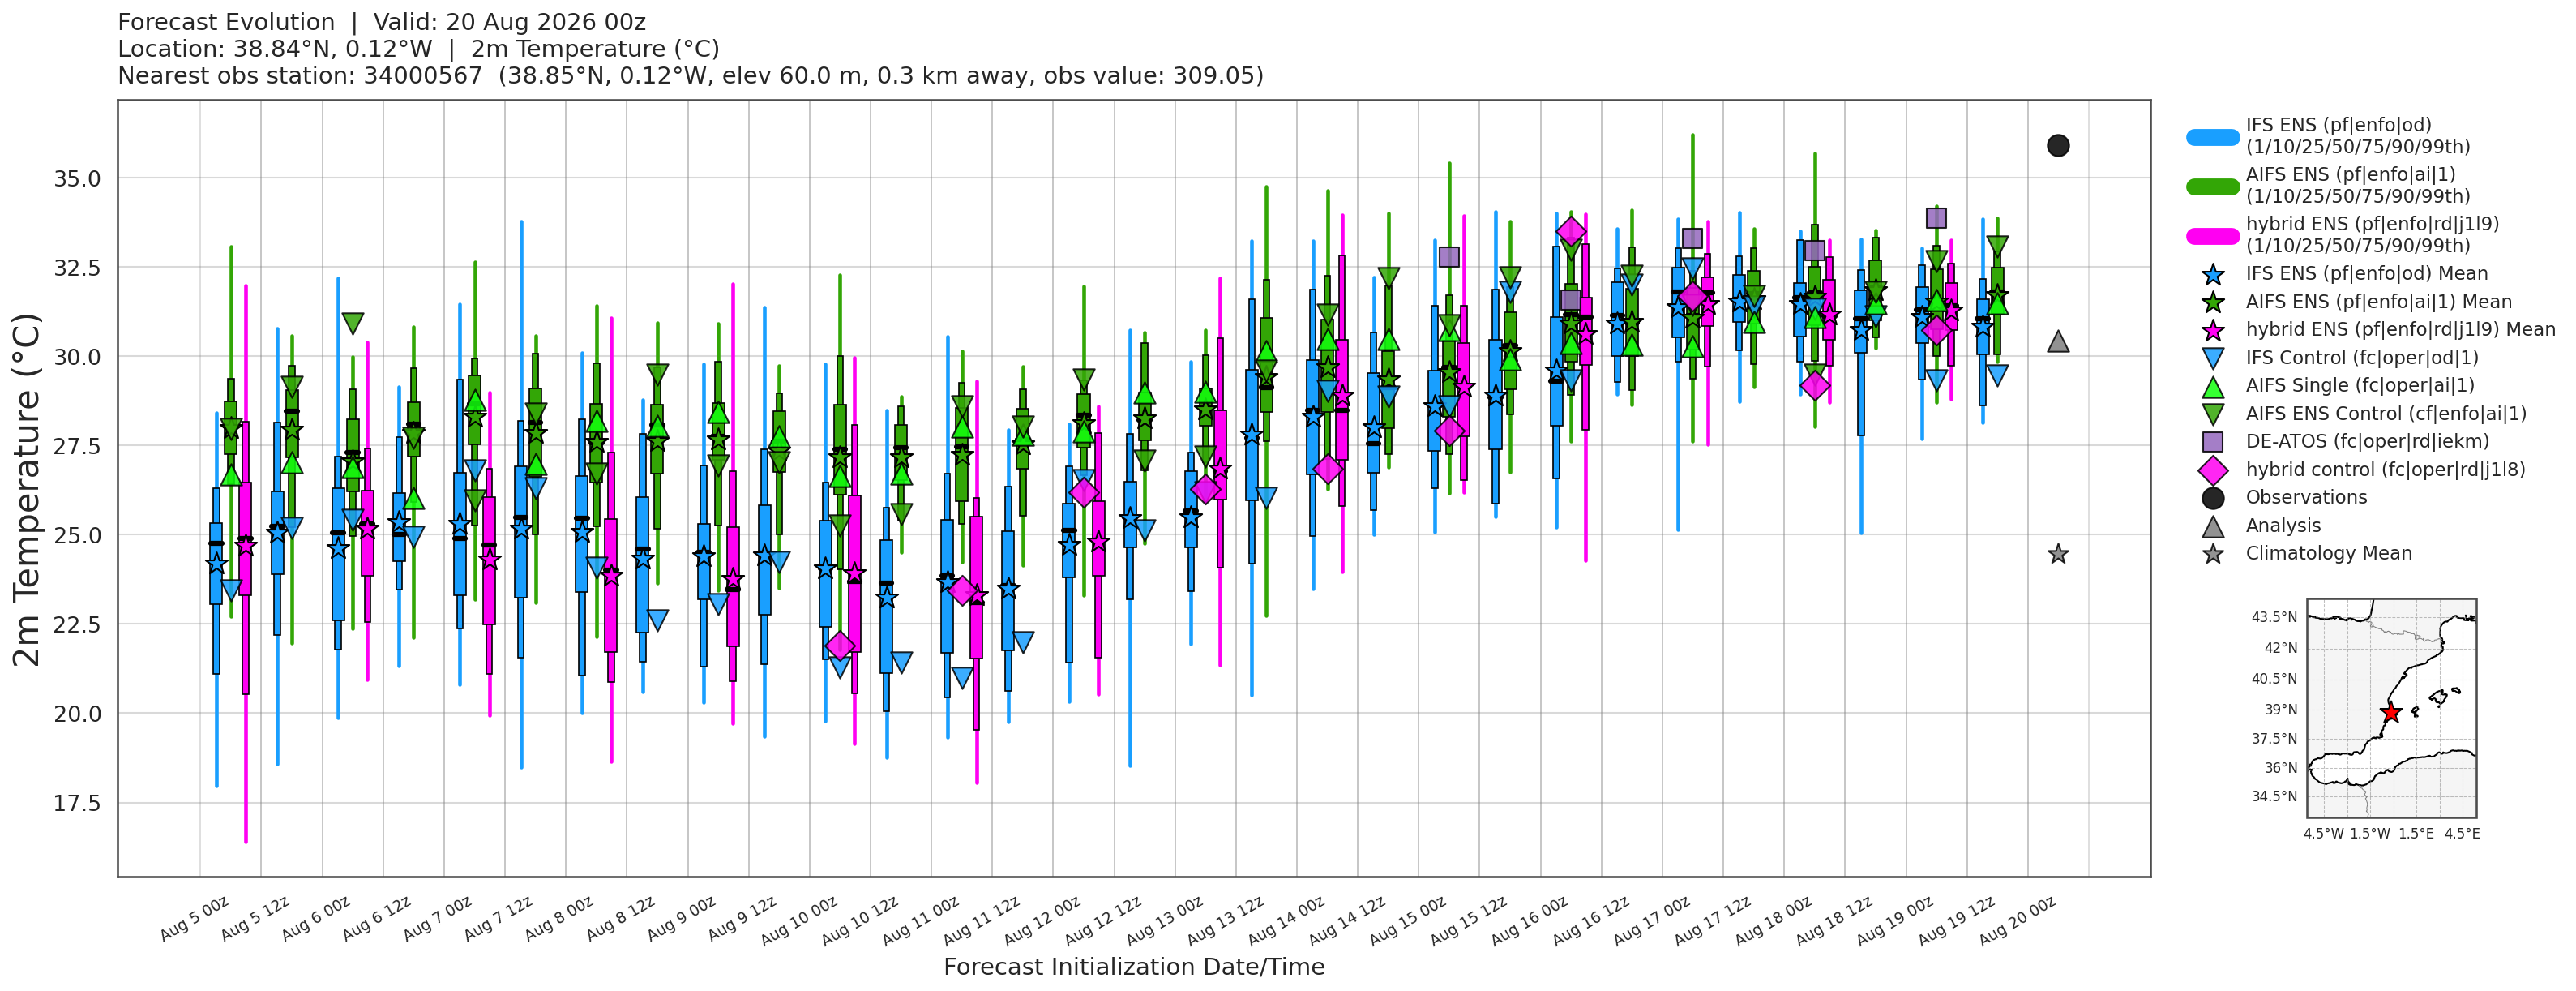

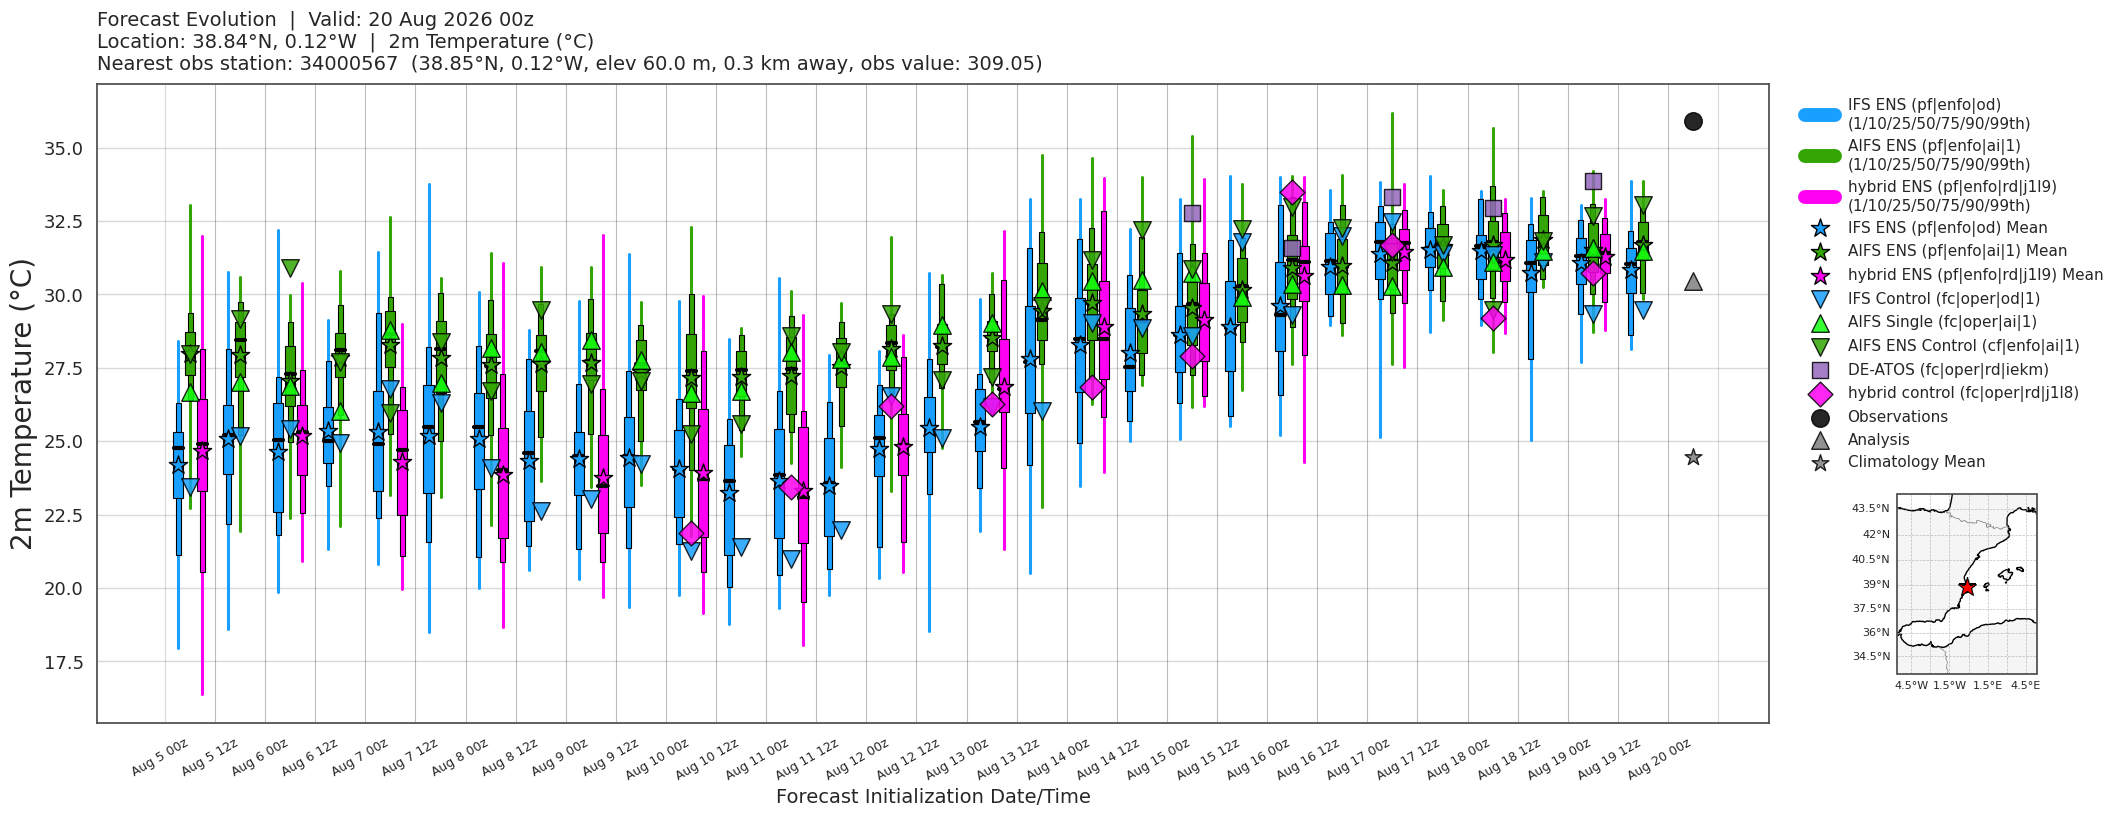

In [19]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=False)

## Step 5 — Map Plots (Metview)

Visualise forecast fields and observations on geographic maps.

### Available map functions

| Function | Description |
|----------|-------------|
| `plot_field_map` | Plot a model's forecast field for a given lead time. Supports `plot_mode='field'` (gridded shading) and `plot_mode='station_nearest'` (nearest-gridpoint values at station locations). |
| `plot_obs_map` | Plot observation station locations and values. |
| `plot_analysis_map` | Plot the analysis field, optionally overlaying observation markers. |

### Key parameters

- **`step`** — Forecast lead time in hours (e.g. `24`, `48`)
- **`plot_mode`** — `'field'` for gridded contour, `'station_nearest'` for station-based extraction
- **`overlay_obs`** — Overlay observation markers on the map (`True` / `False`)
- **`plot_radius`** — Radius in degrees around the selected area for the map extent
- **`export_png`** — Save the plot as a PNG file

In [ ]:
from diag_evo import plot_obs_map, plot_analysis_map, plot_field_map

# Choose the lead times (hours) to plot
lead_times = [36, 60]

for step in lead_times:
    for model in widgets_dict['config']['selected_models']:
        try:
            plot_field_map(plot_data, widgets_dict, model, step=step,
                           plot_mode='field', overlay_obs=True,
                           plot_radius=2, export_png=True)
        except Exception as e:
            print(f"  skip {model} T+{step}h field: {e}")
        try:
            plot_field_map(plot_data, widgets_dict, model, step=step,
                           plot_mode='station_nearest', overlay_obs=False,
                           plot_radius=2, export_png=True)
        except Exception as e:
            print(f"  skip {model} T+{step}h station_nearest: {e}")

In [ ]:
plot_field_map(plot_data, widgets_dict, "DE-ATOS", step=12,
                           plot_mode='field', add_markers=True, overlay_obs=True, 
                           plot_radius=1, export_png=True)

In [ ]:
from diag_evo import plot_obs_map, plot_analysis_map, plot_field_map

plot_field_map(plot_data, widgets_dict, "AIFS ENS", member=20, step=36,
                           plot_mode='field', overlay_obs=True, add_markers=False,
                           plot_radius=0, export_png=True)

In [ ]:
plot_field_map(plot_data, widgets_dict, "AIFSv2 ENS", member=41, step=72,
                           plot_mode='field', overlay_obs=True, add_markers=True,
                           plot_radius=0, export_png=True)

In [ ]:
# Observation and analysis maps
try:
    plot_obs_map(plot_data, widgets_dict, plot_radius=3, export_png=True)
except Exception as e:
    print(f"  skip obs map: {e}")

try:
    plot_analysis_map(plot_data, widgets_dict,
                      overlay_obs=True, plot_radius=3, export_png=True)
except Exception as e:
    print(f"  skip analysis map: {e}")

### Nearest-gridpoint map (point mode only)

Shows the user-selected point, the nearest observation station, and each
model's nearest-gridpoint location (colour-matched to its plot legend
colour) with distances in km. Coastline/land shading lets you see whether
a gridpoint falls on land or over the sea.


In [ ]:
from diag_evo import plot_nearest_gridpoints_map

plot_nearest_gridpoints_map(plot_data, widgets_dict, plot_radius=0.5, export_png=True)


## Optional — Colour Overrides

Override the default plot colours per model before re-plotting.
Set `widgets_dict['config']['model_colors']` to a dict mapping model names to hex colours,
then re-run the plot.

In [ ]:
from diag_evo import get_model_plot_settings

# Build a color map for all selected models
color_map = {}
for model_name in widgets_dict['model_widgets'].value:
    plot_cfg = get_model_plot_settings(model_name)
    color_map[model_name] = plot_cfg['color']

widgets_dict['config']['model_colors'] = color_map
print(color_map)

In [ ]:

widgets_dict['config']['model_colors']={'IFS ENS': '#199fff', 'DE-ATOS': '#9467bd', 'AIFSv2 Single': '#e6194b', 'AIFSv2 ENS': "#008b27", 'AIFSv2 ENS Control': '#f58231'}

In [ ]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)

In [ ]:
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

## Optional — Neighbourhood Ensemble (NB ENS)

> **Only available for 6-hourly accumulated precipitation (`tp`).**

The NB (Neighbourhood) ensemble provides precomputed percentile forecasts. Set `nb_path`
to the directory containing files named:
```
NB_tp6h_p{pctl}.0_rVR_ST0_{YYYYMMDD}_step_6-120.grib2
```

Calling `add_nb_ens_to_plot_data` will:
1. Read the NB GRIB files and extract values at the configured point or area.
2. Expand the 7 precomputed percentiles to a synthetic member distribution so the existing
   plotting functions recover the correct quantiles.
3. Register **NB ENS** as an ensemble model and add it to the active selection.

> **Note:** Only 00 UTC model initialisations are processed; 06,12,18 UTC rows are left as NaN.


In [ ]:
from diag_evo import add_nb_ens_to_plot_data

nb_path = "/ec/vol/destine/neighbourhood/percentile"

plot_data_nb, widgets_dict = add_nb_ens_to_plot_data(plot_data, widgets_dict, nb_path)

# Interactive Plotly plot — NB ENS shown alongside selected models
plot_forecast_evolution(plot_data_nb, widgets_dict, plot_dir, export_html=True)


In [ ]:
# Static matplotlib plot — NB ENS shown alongside selected models
plot_forecast_evolution_static(plot_data_nb, widgets_dict, plot_dir, export_png=True)

## Future Updates

- Statistics (e.g., min, max) over time or area
